In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load the KSE 100 monthly data
kse = pd.read_csv(
    r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\data\processed\kse_monthly_total_return.csv',
    index_col='Date', parse_dates=True
)

# Load the SIP results from Stage 4
sip_aggressive = pd.read_csv(
    r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\data\processed\sip_aggressive.csv',
    index_col='Date', parse_dates=True
)

print(f"Loaded KSE 100 data: {len(kse)} months")
print(f"Loaded SIP results: {len(sip_aggressive)} months")

Loaded KSE 100 data: 179 months
Loaded SIP results: 179 months


In [2]:
# ========================================
# TRANSACTION COSTS (Pakistan-specific)
# ========================================
# Every time you buy stocks on the PSX, you pay these fees:

TRANSACTION_COSTS = {
    'broker_commission_pct': 0.0015,   # 0.15% (typical retail broker rate)
    'cdc_fee_pct': 0.0002,             # 0.02% (Central Depository Company)
    'psx_transaction_pct': 0.0002,     # 0.02% (PSX transaction charge)
    'secp_fee_pct': 0.0001,            # 0.01% (SECP regulatory fee)
    'fed_levy_pct': 0.0001,            # 0.01% (FED levy)
}

# Total cost per transaction (as a fraction of trade value)
TOTAL_BUY_COST_PCT = sum(TRANSACTION_COSTS.values())

print("TRANSACTION COSTS (per buy transaction):")
for name, rate in TRANSACTION_COSTS.items():
    print(f"  {name}: {rate*100:.3f}%")
print(f"\n  TOTAL BUY COST: {TOTAL_BUY_COST_PCT*100:.3f}% per transaction")
print(f"  On PKR 50,000 purchase = PKR {50000 * TOTAL_BUY_COST_PCT:,.0f} in fees")

TRANSACTION COSTS (per buy transaction):
  broker_commission_pct: 0.150%
  cdc_fee_pct: 0.020%
  psx_transaction_pct: 0.020%
  secp_fee_pct: 0.010%
  fed_levy_pct: 0.010%

  TOTAL BUY COST: 0.210% per transaction
  On PKR 50,000 purchase = PKR 105 in fees


In [3]:
# ========================================
# CAPITAL GAINS TAX (CGT) - Pakistan
# ========================================
# CGT on securities is based on holding period:
# - Held < 12 months: 15% of gain
# - Held 12-24 months: 12.5% of gain (was 17.5%, reduced in recent budgets)
# - Held > 24 months: 0% (exempt)
# We'll use these rates for the model.

CGT_RATES = {
    'short_term': 0.15,      # < 12 months
    'medium_term': 0.125,   # 12-24 months
    'long_term': 0.00,      # > 24 months (exempt)
}

print("CAPITAL GAINS TAX RATES:")
print(f"  Held < 12 months:  {CGT_RATES['short_term']*100:.1f}% of gain")
print(f"  Held 12-24 months: {CGT_RATES['medium_term']*100:.1f}% of gain")
print(f"  Held > 24 months:  {CGT_RATES['long_term']*100:.1f}% of gain (exempt)")
print()
print("KEY INSIGHT: In a passive SIP, you hold units for a long time.")
print("Most of your gains are long-term -> 0% CGT. This is a major advantage of passive investing.")

CAPITAL GAINS TAX RATES:
  Held < 12 months:  15.0% of gain
  Held 12-24 months: 12.5% of gain
  Held > 24 months:  0.0% of gain (exempt)

KEY INSIGHT: In a passive SIP, you hold units for a long time.
Most of your gains are long-term -> 0% CGT. This is a major advantage of passive investing.


In [4]:
# ========================================
# SIP ENGINE WITH TRANSACTION COSTS
# ========================================
# Each month, the investor deposits PKR 50,000.
# But they pay ~0.2% in transaction costs on that purchase.
# So the actual amount invested is slightly less.

MONTHLY_INVESTMENT = 50000

def run_sip_with_costs(monthly_investment, returns_series, cost_pct):
    """
    SIP backtest that accounts for transaction costs on every purchase.
    """
    sip = pd.DataFrame(index=returns_series.index)
    
    # Net investment after transaction costs
    sip['Gross_Investment'] = monthly_investment
    sip['Transaction_Cost'] = monthly_investment * cost_pct
    sip['Net_Investment'] = monthly_investment - sip['Transaction_Cost']
    sip['Cumulative_Net_Invested'] = sip['Net_Investment'].cumsum()
    sip['Cumulative_Transaction_Costs'] = sip['Transaction_Cost'].cumsum()
    
    # Simulate portfolio growth (only the net amount gets invested)
    portfolio_value = 0
    portfolio_values = []
    
    for date, monthly_return in returns_series.items():
        # Existing portfolio grows
        portfolio_value = portfolio_value * (1 + monthly_return)
        # Add net investment (after costs)
        portfolio_value += monthly_investment - (monthly_investment * cost_pct)
        portfolio_values.append(portfolio_value)
    
    sip['Portfolio_Value'] = portfolio_values
    sip['Profit_Loss'] = sip['Portfolio_Value'] - sip['Cumulative_Net_Invested']
    sip['Return_on_Invested'] = sip['Profit_Loss'] / sip['Cumulative_Net_Invested']
    
    return sip


# Run the SIP with transaction costs (Aggressive tier)
# We need to reload portfolio_returns since it was defined in Stage 3's notebook
portfolio_returns = pd.read_csv(
    r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\data\processed\portfolio_returns.csv',
    index_col='Date', parse_dates=True
)

sip_with_costs = run_sip_with_costs(
    monthly_investment=MONTHLY_INVESTMENT,
    returns_series=portfolio_returns['Aggressive'],
    cost_pct=TOTAL_BUY_COST_PCT
)

# Compare with the no-cost SIP from Stage 4
print("=== COMPARISON: WITH vs WITHOUT TRANSACTION COSTS ===\n")
print(f"{'Metric':<30} {'No Costs':>15} {'With Costs':>15} {'Difference':>15}")
print("-" * 80)

# No-cost results (from Stage 4)
no_cost_invested = sip_aggressive['Cumulative_Invested'].iloc[-1]
no_cost_value = sip_aggressive['Portfolio_Value'].iloc[-1]
no_cost_profit = sip_aggressive['Profit_Loss'].iloc[-1]
no_cost_return = sip_aggressive['Return_on_Invested'].iloc[-1] * 100

# With-cost results
with_cost_invested = sip_with_costs['Cumulative_Net_Invested'].iloc[-1]
with_cost_value = sip_with_costs['Portfolio_Value'].iloc[-1]
with_cost_profit = sip_with_costs['Profit_Loss'].iloc[-1]
with_cost_return = sip_with_costs['Return_on_Invested'].iloc[-1] * 100

total_costs = sip_with_costs['Cumulative_Transaction_Costs'].iloc[-1]

print(f"{'Total Invested':<30} {no_cost_invested:>15,.0f} {with_cost_invested:>15,.0f} {no_cost_invested-with_cost_invested:>15,.0f}")
print(f"{'Portfolio Value':<30} {no_cost_value:>15,.0f} {with_cost_value:>15,.0f} {no_cost_value-with_cost_value:>15,.0f}")
print(f"{'Profit/Loss':<30} {no_cost_profit:>15,.0f} {with_cost_profit:>15,.0f} {no_cost_profit-with_cost_profit:>15,.0f}")
print(f"{'Return %':<30} {no_cost_return:>14.1f}% {with_cost_return:>14.1f}% {no_cost_return-with_cost_return:>14.1f}%")
print(f"\n{'Total Transaction Costs Paid':<30} {'N/A':>15} {total_costs:>15,.0f}")

=== COMPARISON: WITH vs WITHOUT TRANSACTION COSTS ===

Metric                                No Costs      With Costs      Difference
--------------------------------------------------------------------------------
Total Invested                       8,950,000       8,931,205          18,795
Portfolio Value                     68,162,090      68,018,949         143,140
Profit/Loss                         59,212,090      59,087,744         124,345
Return %                                661.6%          661.6%            0.0%

Total Transaction Costs Paid               N/A          18,795


In [5]:
# ========================================
# DIVIDEND INCOME PROJECTION
# ========================================
# The KSE 100 has an average dividend yield of ~7% per year.
# If the investor holds a portfolio worth X, they receive ~7% * X in dividends per year.
# We'll project this at years 1, 3, 5, 10, and 15.

ANNUAL_DIVIDEND_YIELD = 0.07

# Get portfolio values at key milestones
milestones = {
    'Year 1': 12,
    'Year 3': 36,
    'Year 5': 60,
    'Year 10': 120,
    'Year 15 (final)': len(sip_with_costs) - 1
}

print("=== DIVIDEND INCOME PROJECTION (Aggressive Tier, 7% yield) ===\n")
print(f"{'Milestone':<20} {'Portfolio Value':>18} {'Annual Dividend':>18} {'Monthly Dividend':>18}")
print("-" * 80)

for label, month_idx in milestones.items():
    if month_idx < len(sip_with_costs):
        portfolio_val = sip_with_costs['Portfolio_Value'].iloc[month_idx]
        annual_div = portfolio_val * ANNUAL_DIVIDEND_YIELD
        monthly_div = annual_div / 12
        print(f"{label:<20} {portfolio_val:>18,.0f} {annual_div:>18,.0f} {monthly_div:>18,.0f}")

print()
print("KEY INSIGHT: By Year 10, the portfolio generates more in annual dividends")
print("than the investor's monthly salary contribution. This is the power of compounding.")

=== DIVIDEND INCOME PROJECTION (Aggressive Tier, 7% yield) ===

Milestone               Portfolio Value    Annual Dividend   Monthly Dividend
--------------------------------------------------------------------------------
Year 1                          719,201             50,344              4,195
Year 3                        3,013,253            210,928             17,577
Year 5                        7,885,440            551,981             45,998
Year 10                      15,122,057          1,058,544             88,212
Year 15 (final)              68,018,949          4,761,326            396,777

KEY INSIGHT: By Year 10, the portfolio generates more in annual dividends
than the investor's monthly salary contribution. This is the power of compounding.


In [6]:
# ========================================
# CAPITAL GAINS TAX ON EXIT
# ========================================
# When the investor sells everything at the end, they pay CGT.
# In a SIP, different units have different holding periods:
# - Units bought in the first 22 months: held > 24 months -> 0% CGT
# - Units bought in months 23-24: held 12-24 months -> 12.5% CGT
# - Units bought in last 12 months: held < 12 months -> 15% CGT

# Simplified model: calculate average holding period and blended CGT rate
total_months = len(sip_with_costs)
final_value = sip_with_costs['Portfolio_Value'].iloc[-1]
total_invested = sip_with_costs['Cumulative_Net_Invested'].iloc[-1]
total_gain = final_value - total_invested

# Calculate what fraction of units fall into each CGT bracket
# (assuming equal monthly investments)
long_term_months = max(0, total_months - 24)  # held > 24 months
medium_term_months = min(12, total_months)   # held 12-24 months (last 12-24 months of buying)
short_term_months = min(12, total_months)    # held < 12 months (last 12 months of buying)

# Adjust for the actual length
if total_months > 24:
    long_term_fraction = long_term_months / total_months
    medium_term_fraction = 12 / total_months
    short_term_fraction = 12 / total_months
else:
    long_term_fraction = 0
    medium_term_fraction = max(0, total_months - 12) / total_months
    short_term_fraction = min(12, total_months) / total_months

# Blended CGT rate
blended_cgt_rate = (
    long_term_fraction * CGT_RATES['long_term'] +
    medium_term_fraction * CGT_RATES['medium_term'] +
    short_term_fraction * CGT_RATES['short_term']
)

# CGT amount
cgt_amount = total_gain * blended_cgt_rate

# After-tax value
after_tax_value = final_value - cgt_amount
after_tax_profit = after_tax_value - total_invested

print("=== CAPITAL GAINS TAX ON EXIT (sell everything at end) ===\n")
print(f"Total months invested:          {total_months}")
print(f"Final portfolio value:          PKR {final_value:,.0f}")
print(f"Total invested:                 PKR {total_invested:,.0f}")
print(f"Total gain:                     PKR {total_gain:,.0f}")
print()
print(f"Long-term fraction (>24mo):    {long_term_fraction*100:.1f}% (0% CGT)")
print(f"Medium-term fraction (12-24mo):{medium_term_fraction*100:.1f}% (12.5% CGT)")
print(f"Short-term fraction (<12mo):   {short_term_fraction*100:.1f}% (15% CGT)")
print(f"Blended CGT rate:               {blended_cgt_rate*100:.2f}%")
print()
print(f"CGT payable:                    PKR {cgt_amount:,.0f}")
print(f"After-tax portfolio value:     PKR {after_tax_value:,.0f}")
print(f"After-tax profit:              PKR {after_tax_profit:,.0f}")
print(f"After-tax return on invested:  {after_tax_profit/total_invested*100:.1f}%")

=== CAPITAL GAINS TAX ON EXIT (sell everything at end) ===

Total months invested:          179
Final portfolio value:          PKR 68,018,949
Total invested:                 PKR 8,931,205
Total gain:                     PKR 59,087,744

Long-term fraction (>24mo):    86.6% (0% CGT)
Medium-term fraction (12-24mo):6.7% (12.5% CGT)
Short-term fraction (<12mo):   6.7% (15% CGT)
Blended CGT rate:               1.84%

CGT payable:                    PKR 1,089,327
After-tax portfolio value:     PKR 66,929,622
After-tax profit:              PKR 57,998,417
After-tax return on invested:  649.4%


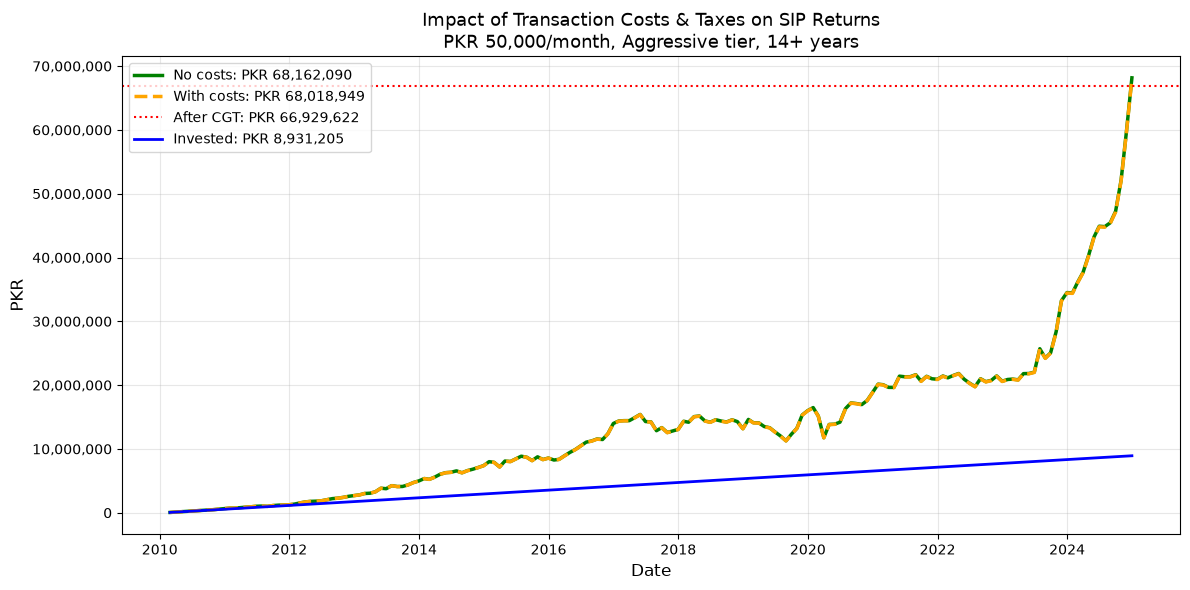

Chart saved to docs/impact_of_costs.png

=== SUMMARY: COST IMPACT OVER 179 MONTHS ===
Total transaction costs paid:  PKR 18,795
Capital gains tax on exit:     PKR 1,089,327
Total costs + tax:             PKR 1,108,122
Final after-tax value:         PKR 66,929,622
Final after-tax return:        649.4%


In [7]:
# ========================================
# CHART: How Costs Eat Your Returns
# ========================================
fig, ax = plt.subplots(figsize=(12, 6))

# Plot portfolio value without costs
ax.plot(sip_aggressive.index, sip_aggressive['Portfolio_Value'],
        color='green', linewidth=2.5, label=f'No costs: PKR {no_cost_value:,.0f}')

# Plot portfolio value with costs
ax.plot(sip_with_costs.index, sip_with_costs['Portfolio_Value'],
        color='orange', linewidth=2.5, linestyle='--',
        label=f'With costs: PKR {with_cost_value:,.0f}')

# Plot after-tax value as a horizontal line
ax.axhline(y=after_tax_value, color='red', linewidth=1.5, linestyle=':',
           label=f'After CGT: PKR {after_tax_value:,.0f}')

# Plot cumulative invested
ax.plot(sip_with_costs.index, sip_with_costs['Cumulative_Net_Invested'],
        color='blue', linewidth=2, label=f'Invested: PKR {with_cost_invested:,.0f}')

ax.set_title(f'Impact of Transaction Costs & Taxes on SIP Returns\n'
             f'PKR {MONTHLY_INVESTMENT:,.0f}/month, Aggressive tier, 14+ years',
             fontsize=13)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('PKR', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\docs\impact_of_costs.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to docs/impact_of_costs.png")
print()
print(f"=== SUMMARY: COST IMPACT OVER {total_months} MONTHS ===")
print(f"Total transaction costs paid:  PKR {total_costs:,.0f}")
print(f"Capital gains tax on exit:     PKR {cgt_amount:,.0f}")
print(f"Total costs + tax:             PKR {total_costs + cgt_amount:,.0f}")
print(f"Final after-tax value:         PKR {after_tax_value:,.0f}")
print(f"Final after-tax return:        {after_tax_profit/total_invested*100:.1f}%")

In [8]:
# Save the SIP with costs
sip_with_costs.to_csv(
    r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\data\processed\sip_with_costs.csv'
)

print("Results saved to data/processed/sip_with_costs.csv")
print(f"Rows: {len(sip_with_costs)}")
print(f"Columns: {list(sip_with_costs.columns)}")

Results saved to data/processed/sip_with_costs.csv
Rows: 179
Columns: ['Gross_Investment', 'Transaction_Cost', 'Net_Investment', 'Cumulative_Net_Invested', 'Cumulative_Transaction_Costs', 'Portfolio_Value', 'Profit_Loss', 'Return_on_Invested']
